# DEMOGRAPHIC TREND AND MIGRATION ANALYSIS

##### Overview:
This project involves exploratory data analysis (EDA) of demographic dataset containing 320 records and 4 attributes. The dataset has multiple countries and years with two key indicators: total population which indicate the number of residents  in each country and net migration which shows the difference between people who entering (immigrants) and leaving (emigrants) the countries. 

##### Purpose:

Through EDA, the analysis aims to uncover population trends, analyze migration pattern, detect and remove outliers and understand the relationship between population growth and migration.

### Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [27]:
df = pd.read_csv(r"C:\Users\DHANYA\Downloads\archive (2).zip")
print("Dataset is loaded successfully")

Dataset is loaded successfully


In [4]:
df

,Country,Year,total_population,net_migration
0,Afghanistan,2023,42239854.0,-65846.0
1,Afghanistan,2022,41128771.0,-65846.0
2,Afghanistan,2021,40099462.0,-183672.0
3,Afghanistan,2020,38972230.0,166821.0
4,Afghanistan,2019,37769499.0,-8082.0
...,...,...,...,...
315,Pakistan,1964,50552592.0,-126712.0
316,Pakistan,1963,49325050.0,-129202.0
317,Pakistan,1962,48161841.0,-131607.0
318,Pakistan,1961,47060915.0,-133982.0


### Clean the data

In [3]:
# Checking Missing Values

df.isnull().sum()

Country             0
Year                0
total_population    0
net_migration       0
dtype: int64

In [4]:
# Checking data types

df.dtypes

Country              object
Year                  int64
total_population    float64
net_migration       float64
dtype: object

In [5]:
# Checking Duplicate Values

df.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis (EDA)

In [7]:
# Statistical Summary

df.describe()

,Year,total_population,net_migration
count,320.000000,3.200000e+02,3.200000e+02
mean,1991.500000,2.381422e+08,-1.746498e+05
std,18.501885,3.708735e+08,4.372562e+05
min,1960.000000,8.622466e+06,-2.290411e+06
25%,1975.750000,1.888430e+07,-2.873812e+05
50%,1991.500000,7.269946e+07,-8.455950e+04
75%,2007.250000,1.829264e+08,-8.405000e+02
max,2023.000000,1.428628e+09,1.834556e+06


In [6]:
# Name of all countries

df['Country'].unique()

array(['Afghanistan', 'Bangladesh', 'India', 'Sri Lanka', 'Pakistan'],
      dtype=object)

In [6]:
df.columns

Index(['Country', 'Year', 'total_population', 'net_migration'], dtype='object')

In [25]:
# Most populous countries per year along with average net migration

grouped = df.groupby(['Year','Country']).agg({ 'total_population':'mean', 'net_migration':'mean'}).sort_values(by='total_population',ascending=False).head(5)

In [26]:
grouped

,,total_population,net_migration
Year,Country,,
2023,India,1.428628e+09,-486136.0
2022,India,1.417173e+09,-487303.0
2021,India,1.407564e+09,-301970.0
2020,India,1.396387e+09,-34772.0
2019,India,1.383112e+09,-593495.0


##### Insight:
- The most populous country is India.
- India's population steadily increased from 2019 to 2023 showing consistent growth year after year.
- Net migration values are negative which means outflow of people from India is more than inflow of people.
- While population is increasing, net migration remaining negative suggesting that population growth is driven by increase in birth rate rather than immigrant.


In [27]:
# Immigrant Analysis

top_immigrant_countries = df.groupby('Country')['net_migration'].sum().sort_values(ascending=False).head()

In [28]:
top_immigrant_countries

Country
Afghanistan    -2570326.0
Sri Lanka      -3077939.0
India         -11247041.0
Pakistan      -18487914.0
Bangladesh    -20504716.0
Name: net_migration, dtype: float64

In [29]:
# Emigrant Analysis

top_emigrant_countries= df.groupby('Country')['net_migration'].sum().sort_values(ascending=True).head()

In [30]:
top_emigrant_countries

Country
Bangladesh    -20504716.0
Pakistan      -18487914.0
India         -11247041.0
Sri Lanka      -3077939.0
Afghanistan    -2570326.0
Name: net_migration, dtype: float64

##### Insight:
- All listed countries show negative net migration. These means more people are leaving than entering.
- Top immigrant countries are Afghanistan, Sri Lanka have negative net migration. This means these countries are not destinations for migrants but are source of migrants.
- Top emigrant countries are Bangladesh, Pakistan and India. This suggest strong reasons like economic, social or political pressure driving people to leave.
- Since all five countries are in South Asia, the region can be seen as a major source of emigrants globally.

In [74]:
# Year-Over-Year Growth Rate

df['Growth Rate'] = df.groupby('Country')['total_population'].pct_change()*100

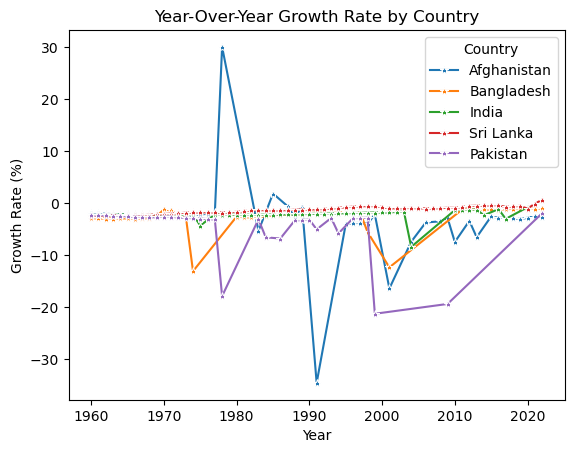

In [75]:
# Visualize Year-Over-Year Growth Rate using Line Chart

sns.lineplot(data=df, x='Year', y='Growth Rate', hue='Country', marker='*')
plt.title('Year-Over-Year Growth Rate by Country')
plt.ylabel('Growth Rate (%)')
plt.show()

##### Insight:
- From 1960 to 2020 more people are leaving from the given listed South Asian Countries.
- Except during 1980s, the graph shows there is a rise in immigrant in Afghanistan.

In [11]:
df.head()

,Country,Year,total_population,net_migration,Growth Rate
0,Afghanistan,2023,42239854.0,-65846.0,NaN
1,Afghanistan,2022,41128771.0,-65846.0,-2.630414
2,Afghanistan,2021,40099462.0,-183672.0,-2.502650
3,Afghanistan,2020,38972230.0,166821.0,-2.811090
4,Afghanistan,2019,37769499.0,-8082.0,-3.086123


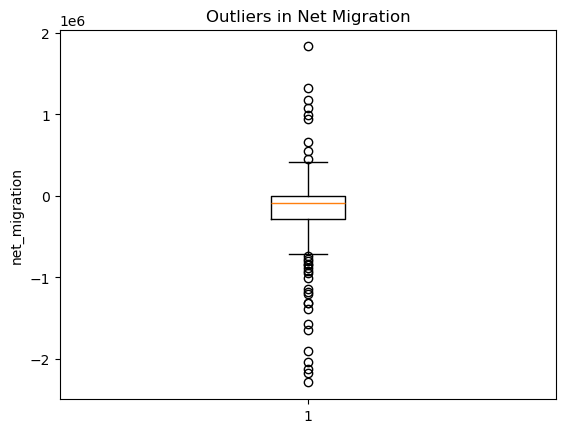

In [28]:
# Detect Outliers in Net Migration

plt.boxplot(df['net_migration'])
plt.title('Outliers in Net Migration')
plt.ylabel('net_migration')
plt.show()

In [69]:
# Correcting Outliers using Interquartile Range (IQR) Method

Q1 = df['net_migration'].quantile(0.25)
Q3 = df['net_migration'].quantile(0.75)

In [70]:
IQR = Q3-Q1

In [71]:
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR

In [72]:
df = df[(df['net_migration'] >= lower_limit) & (df['net_migration'] <= upper_limit)]

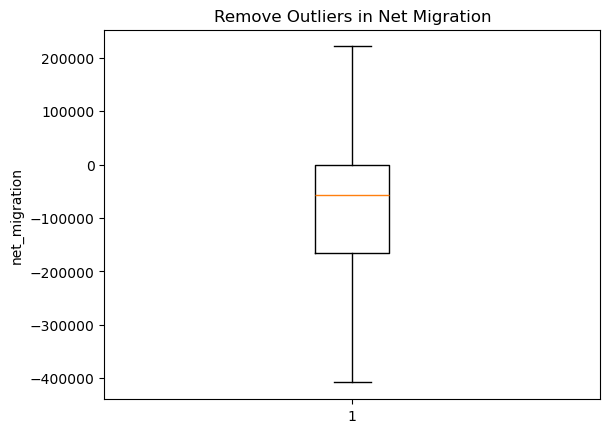

In [82]:
# Checking Correction on  Net Migration Outliers 

plt.boxplot(df['net_migration'])
plt.title('Remove Outliers in Net Migration')
plt.ylabel('net_migration')
plt.show()

In [76]:
df

,Country,Year,total_population,net_migration,Growth Rate
0,Afghanistan,2023,42239854.0,-65846.0,NaN
1,Afghanistan,2022,41128771.0,-65846.0,-2.630414
2,Afghanistan,2021,40099462.0,-183672.0,-2.502650
3,Afghanistan,2020,38972230.0,166821.0,-2.811090
4,Afghanistan,2019,37769499.0,-8082.0,-3.086123
...,...,...,...,...,...
315,Pakistan,1964,50552592.0,-126712.0,-2.486485
316,Pakistan,1963,49325050.0,-129202.0,-2.428247
317,Pakistan,1962,48161841.0,-131607.0,-2.358252
318,Pakistan,1961,47060915.0,-133982.0,-2.285889


In [79]:
# Correlation between Population and Migration

df[['total_population','net_migration']].corr()

,total_population,net_migration
total_population,1.000000,-0.123155
net_migration,-0.123155,1.000000


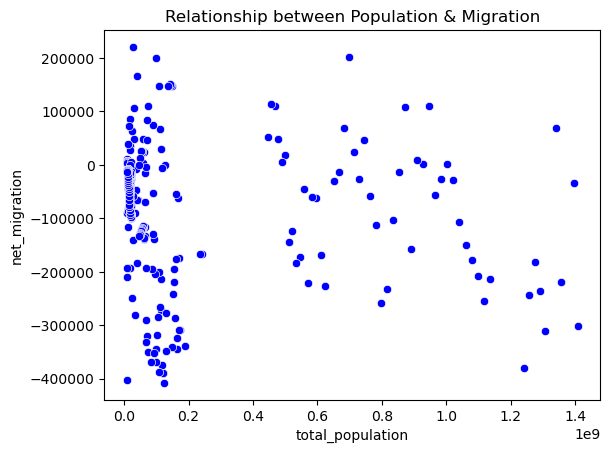

In [80]:
# Visualize the Relationship between Population & Migration

sns.scatterplot(x='total_population', y='net_migration', color='blue',data=df)
plt.title('Relationship between Population & Migration')
plt.show()
          

##### Insight:
- Correlation value is-0.123 shows there is a weak negative correlation between total population and net migration.
- Migration patterns in these South Asian countries are not strongly driven by population size alone; other factors including economic, political, social also likely to be influenced.
- Population growth and net migration are largely independent in this dataset, with only a minor inverse association.

### Export as CSV

In [83]:
df.to_csv("cleaned_population_&_net_migration_dataset.csv",index = False)